In [1]:
import importlib
import importlib.machinery
import io
import os
import sys
import types
import uuid
from datetime import datetime
from pathlib import Path

import cv2
import duckdb
import faiss
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import polars as pl
import requests
import torch
from PIL import Image
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoProcessor,
    CLIPModel,
    CLIPProcessor,
)
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

c:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
MODEL_PATH = r"C:\Users\krist\runs\detect\yolo11s_SKU110K5\weights\best.pt"
# MODEL_PATH = r"C:\Users\krist\runs\detect\train6" # yolov8n

IMAGE_PATH = (
    r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef"
    r"\bachproef26\latex-hogent-bachproef\bachproef\datasets"
    r"\SKU-110K_fixed\images\test_16.jpg"
)

PARQUET_PATH = (
    r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef"
    r"\bachproef26\latex-hogent-bachproef\bachproef\datasets\food_images_long.parquet"
)

CROPS_ROOT   = "./crops"
INDEX_CACHE = r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\faiss_index2.bin"
META_CACHE  = r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\datasets\faiss_meta2.parquet"

CLIP_WEIGHT = 0.55   
OCR_WEIGHT = 0.45   

CONF         = 0.25  
TOP_K        = 5    

print("Variabelen ingeladen")

Variabelen ingeladen


In [3]:
#Florence-2
flash_attn = types.ModuleType("flash_attn")
flash_attn.__spec__ = importlib.machinery.ModuleSpec("flash_attn", None)
flash_attn_interface = types.ModuleType("flash_attn.flash_attn_interface")
flash_attn_interface.__spec__ = importlib.machinery.ModuleSpec("flash_attn.flash_attn_interface", None)
sys.modules["flash_attn"] = flash_attn
sys.modules["flash_attn.flash_attn_interface"] = flash_attn_interface
os.environ["FLASH_ATTENTION_FORCE_DISABLED"] = "1"

fl2_model_id  = "microsoft/Florence-2-base"
fl2_processor = AutoProcessor.from_pretrained(fl2_model_id, trust_remote_code=True)
fl2_model     = AutoModelForCausalLM.from_pretrained(
    fl2_model_id, trust_remote_code=True, attn_implementation="eager"
).to(device)
fl2_model.eval()
print("Florence-2 loaded")

# CLIP
FINETUNED_PATH = r".\clip\clip_finetuned"
clip_model     = CLIPModel.from_pretrained(FINETUNED_PATH).to(device)
clip_processor = CLIPProcessor.from_pretrained(FINETUNED_PATH)
clip_model.eval()
print("CLIP loaded")

#YOLO
yolo = YOLO(MODEL_PATH)
print("YOLO loaded")

Florence-2 loaded
CLIP loaded
YOLO loaded


In [4]:
@torch.no_grad()
def clip_embed(pil_image: Image.Image) -> np.ndarray:
    """Returns a normalised CLIP visual embedding (512-d)."""
    inputs = clip_processor(images=pil_image, return_tensors="pt").to(device)
    feats  = clip_model.get_image_features(**inputs)          # (1, 512)
    vec    = feats.squeeze().detach().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)


@torch.no_grad()
def fl2_embed(pil_image: Image.Image) -> np.ndarray:
    """Florence-2 visual embedding — uses _encode_image which is the correct internal API."""
    pixel_values = fl2_processor(images=pil_image, return_tensors="pt").pixel_values.to(device)
    
    visual_feats = fl2_model._encode_image(pixel_values)  # (1, num_tokens, lm_hidden)
    
    vec = visual_feats.mean(dim=1).squeeze().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)

@torch.no_grad()
def fl2_ocr_text(pil_image: Image.Image) -> str:
    """Run Florence-2 OCR and return the extracted text string."""
    inputs = fl2_processor(
        images=pil_image,
        text="<OCR>",
        return_tensors="pt"
    ).to(device)

    generated = fl2_model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=128,
        num_beams=1,        
        do_sample=False,
        early_stopping=False,
    )

    result = fl2_processor.batch_decode(generated, skip_special_tokens=True)[0]
    return result.strip()


def fl2_ocr_embed(pil_image: Image.Image) -> np.ndarray:
    text = fl2_ocr_text(pil_image)
    if not text:
        return np.zeros(512, dtype=np.float32)

    inputs = clip_processor(text=[text], return_tensors="pt", truncation=True).to(device)
    feats  = clip_model.get_text_features(**inputs)
    vec    = feats.squeeze().detach().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)

def fused_embed(pil_image: Image.Image) -> np.ndarray:
    clip_img = clip_embed(pil_image)        
    ocr_vec  = fl2_ocr_embed(pil_image)     
    fl2_vis  = fl2_embed(pil_image)        

    fused = np.concatenate([
        CLIP_WEIGHT * clip_img,
        OCR_WEIGHT * ocr_vec,
    ])
    return fused / (np.linalg.norm(fused) + 1e-9)

EMBED_DIM = 512 + 512
print(f"Fused embedding dim: {EMBED_DIM}")

Fused embedding dim: 1024


In [12]:
df_foodfacts = duckdb.query(f"""
    SELECT DISTINCT ON (product_name) *
    FROM '{PARQUET_PATH}'
    WHERE image_key LIKE '%front%'
    ORDER BY code ASC
    LIMIT 1000
""").pl()

print(f"Rows    : {len(df_foodfacts):,}")
print(f"Columns : {df_foodfacts.columns}")
df_foodfacts.head(5)

Rows    : 1,000
Columns : ['code', 'product_name', 'image_key', 'image_url']


code,product_name,image_key,image_url
str,str,str,str
"""00000024""","""croccante con pistacchi e miel…","""front_fr""","""https://images.openfoodfacts.o…"
"""00000042""","""multivitamins minerals""","""front_fr""","""https://images.openfoodfacts.o…"
"""00000062""","""abricots""","""front_fr""","""https://images.openfoodfacts.o…"
"""00000178""","""dattes mejdoul""","""front_et""","""https://images.openfoodfacts.o…"
"""00000205""","""canard a l orange""","""front_fr""","""https://images.openfoodfacts.o…"


In [13]:
def fetch_pil(url: str, timeout: int = 10):
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return Image.open(io.BytesIO(r.content)).convert("RGB")
    except Exception:
        return None


PROGRESS_DIR = Path("./faiss_cor_indexed")

def embed_new_rows(df: pl.DataFrame):
    """Only embed rows not yet in PROGRESS_DIR. Saves each as code__image_key.npy."""
    PROGRESS_DIR.mkdir(exist_ok=True)
    n_ok = n_skip = n_fail = 0

    for row in tqdm(df.iter_rows(named=True), total=len(df), desc="Embedding new rows"):
        code      = str(row.get("code", "unknown")).replace("/", "_")
        image_key = str(row.get("image_key", "unknown")).replace("/", "_")
        cache_file = PROGRESS_DIR / f"{code}__{image_key}.npy"

        if cache_file.exists():
            n_skip += 1
            continue

        url = row.get("image_url") or row.get("url") or ""
        img = fetch_pil(url)
        if img is None:
            continue

        try:
            vec = fused_embed(img)
            np.save(str(cache_file), vec)
            n_ok += 1
        except Exception as e:
            n_fail += 1
            if n_fail <= 3:
                print(f"  [embed error] {code}/{image_key}: {type(e).__name__}: {e}")

    print(f"Embedding done — {n_ok} new  |  {n_skip} skipped  |  {n_fail} failed")


def build_index_from_folder(df: pl.DataFrame) -> tuple[faiss.Index, pl.DataFrame]:
    """
    Build FAISS index from ALL .npy files in PROGRESS_DIR.
    Only includes rows from df that have a matching .npy file.
    """
    embeddings = []
    valid_rows = []

    for row in tqdm(df.iter_rows(named=True), total=len(df), desc="Loading from folder"):
        code      = str(row.get("code", "unknown")).replace("/", "_")
        image_key = str(row.get("image_key", "unknown")).replace("/", "_")
        cache_file = PROGRESS_DIR / f"{code}__{image_key}.npy"

        if not cache_file.exists():
            continue 

        embeddings.append(np.load(str(cache_file)))
        valid_rows.append(row)

    print(f"Loaded {len(embeddings):,} vectors from {PROGRESS_DIR}")

    if not embeddings:
        raise RuntimeError("No embeddings found in folder.")

    matrix = np.stack(embeddings).astype("float32")
    index  = faiss.IndexFlatIP(EMBED_DIM)
    index.add(matrix)
    return index, pl.DataFrame(valid_rows)


embed_new_rows(df_foodfacts)

Path(INDEX_CACHE).unlink(missing_ok=True)
Path(META_CACHE).unlink(missing_ok=True)

index, meta_df = build_index_from_folder(df_foodfacts)
faiss.write_index(index, INDEX_CACHE)
meta_df.write_parquet(META_CACHE)
print(f"Saved: {index.ntotal:,} vectors")

Embedding new rows: 100%|██████████| 1000/1000 [03:00<00:00,  5.54it/s]


Embedding done — 0 new  |  982 skipped  |  0 failed


Loading from folder: 100%|██████████| 1000/1000 [00:16<00:00, 61.25it/s]


Loaded 982 vectors from faiss_cor_indexed
Saved: 982 vectors


In [7]:
# input afbeelding inladen
image_path = Path(IMAGE_PATH)
assert image_path.exists(), f"Image not found: {image_path}"

img_bgr = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_bgr.shape[:2]

# YOLO runnen
results = yolo.predict(source=str(image_path), conf=CONF, verbose=False)
boxes   = results[0].boxes
n_det   = 0 if boxes is None else len(boxes)
print(f"Detections: {n_det}")

# output folder maken zodat het opgeslagen kan worden
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
short_uid = uuid.uuid4().hex[:8]
run_dir   = Path(CROPS_ROOT) / f"{timestamp}_{short_uid}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {run_dir.resolve()}")

Detections: 188
Output dir: C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\crops\20260504_133421_9884c6b5


In [14]:
def search(pil_image: Image.Image, k: int = TOP_K):
    """Embed pil_image, query FAISS, return (scores, metadata rows)."""
    vec        = fused_embed(pil_image).reshape(1, -1).astype("float32")
    scores, idxs = index.search(vec, k)
    scores, idxs = scores[0], idxs[0]

    matches = []
    for score, idx in zip(scores, idxs):
        if idx == -1:
            continue
        row = meta_df.row(idx, named=True)
        matches.append({
            "similarity"   : float(score),
            "code"         : row.get("code"),
            "product_name" : row.get("product_name"),
            "image_url"    : row.get("image_url") or row.get("url"),
        })
    return matches


all_results = [] 

for i, box in enumerate(tqdm(boxes, desc="Processing crops")):
    # ── Crop ──────────────────────────────────────────────────────────────────
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    x1 = max(0, int(round(x1)))
    y1 = max(0, int(round(y1)))
    x2 = min(w, int(round(x2)))
    y2 = min(h, int(round(y2)))

    if x2 <= x1 or y2 <= y1:
        continue

    conf_val   = float(box.conf[0])
    crop_bgr   = img_bgr[y1:y2, x1:x2]
    crop_pil   = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))

    # ── Save crop ─────────────────────────────────────────────────────────────
    crop_name  = f"{i:04d}_conf{conf_val:.2f}.jpg"
    crop_path  = run_dir / crop_name
    crop_pil.save(str(crop_path))

    # ── Match ─────────────────────────────────────────────────────────────────
    matches = search(crop_pil)
    all_results.append((crop_pil, crop_path, matches))

print(f"\nDone. Processed {len(all_results)} crop(s).")

Processing crops: 100%|██████████| 188/188 [01:01<00:00,  3.05it/s]


Done. Processed 188 crop(s).


In [89]:
coke_rows = df_foodfacts.filter(
    pl.col("product_name").str.to_lowercase().str.contains("coca")
)
print(f"Coca-Cola rows in dataset: {len(coke_rows)}")
print(coke_rows.select(["code", "product_name", "image_url"]).head(25))

Coca-Cola rows in dataset: 0
shape: (0, 3)
┌──────┬──────────────┬───────────┐
│ code ┆ product_name ┆ image_url │
│ ---  ┆ ---          ┆ ---       │
│ str  ┆ str          ┆ str       │
╞══════╪══════════════╪═══════════╡
└──────┴──────────────┴───────────┘


Showing crops: [4, 24, 49, 99, 149] (out of 188 total)


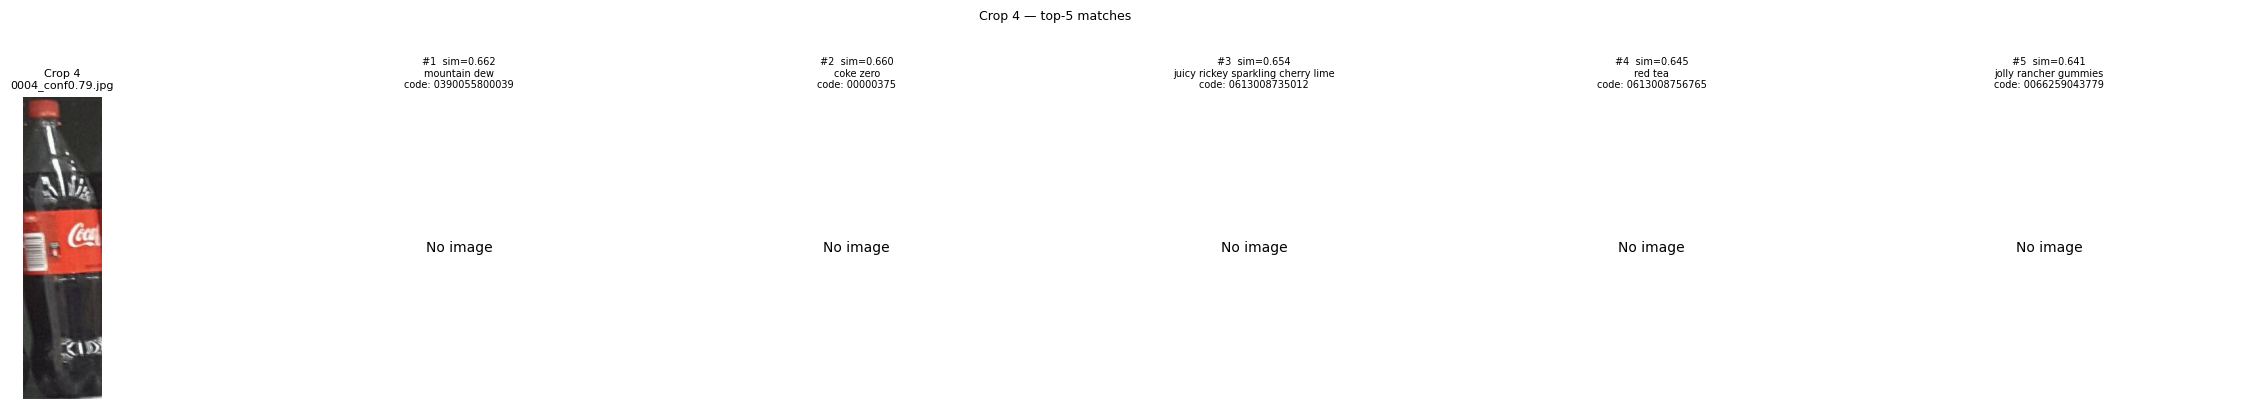


  Crop 4 best matches:
    #1  sim=0.6615  code=0390055800039  name=mountain dew
         url=https://images.openfoodfacts.org/images/products/039/005/580/0039/front_fr.3.400.jpg
    #2  sim=0.6601  code=00000375  name=coke zero
         url=https://images.openfoodfacts.org/images/products/000/000/000/0375/front_fr.16.400.jpg
    #3  sim=0.6543  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #4  sim=0.6453  code=0613008756765  name=red tea
         url=https://images.openfoodfacts.org/images/products/061/300/875/6765/front_fr.23.400.jpg
    #5  sim=0.6406  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg



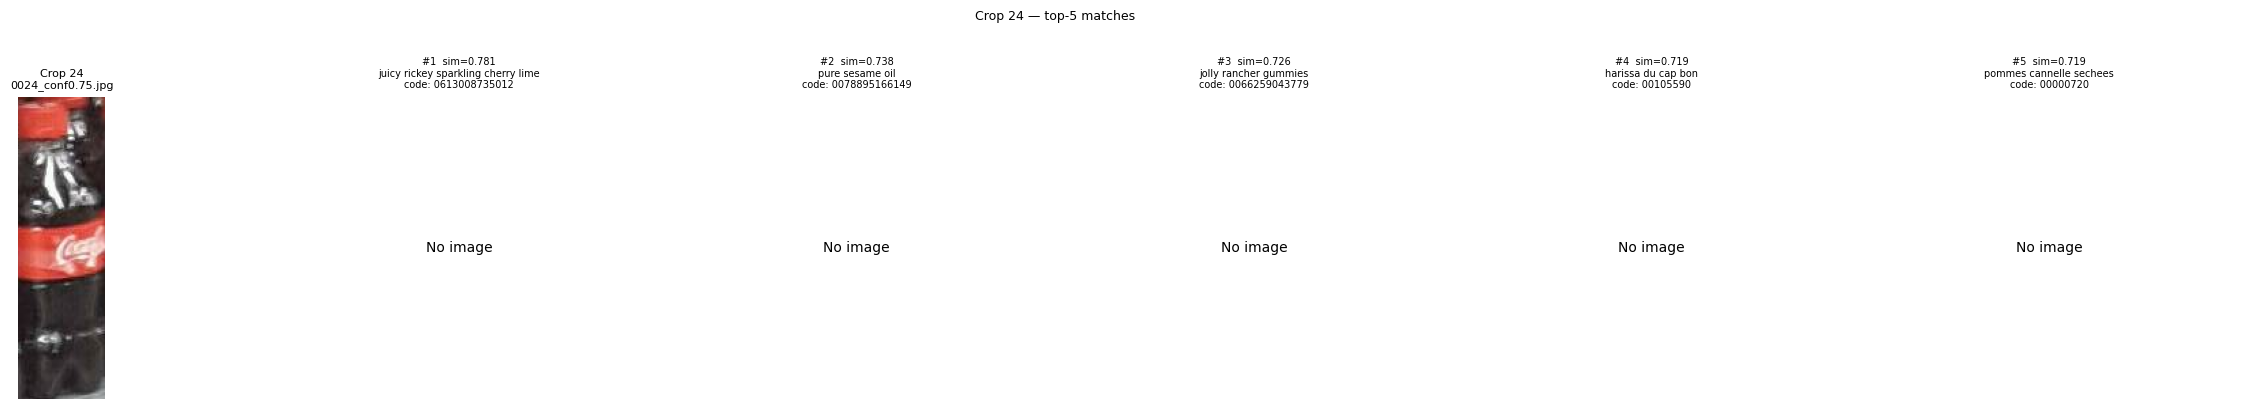


  Crop 24 best matches:
    #1  sim=0.7812  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #2  sim=0.7379  code=0078895166149  name=pure sesame oil
         url=https://images.openfoodfacts.org/images/products/007/889/516/6149/front_en.23.400.jpg
    #3  sim=0.7257  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg
    #4  sim=0.7186  code=00105590  name=harissa du cap bon
         url=https://images.openfoodfacts.org/images/products/000/000/010/5590/front_en.3.400.jpg
    #5  sim=0.7185  code=00000720  name=pommes cannelle sechees
         url=https://images.openfoodfacts.org/images/products/000/000/000/0720/front_en.17.400.jpg



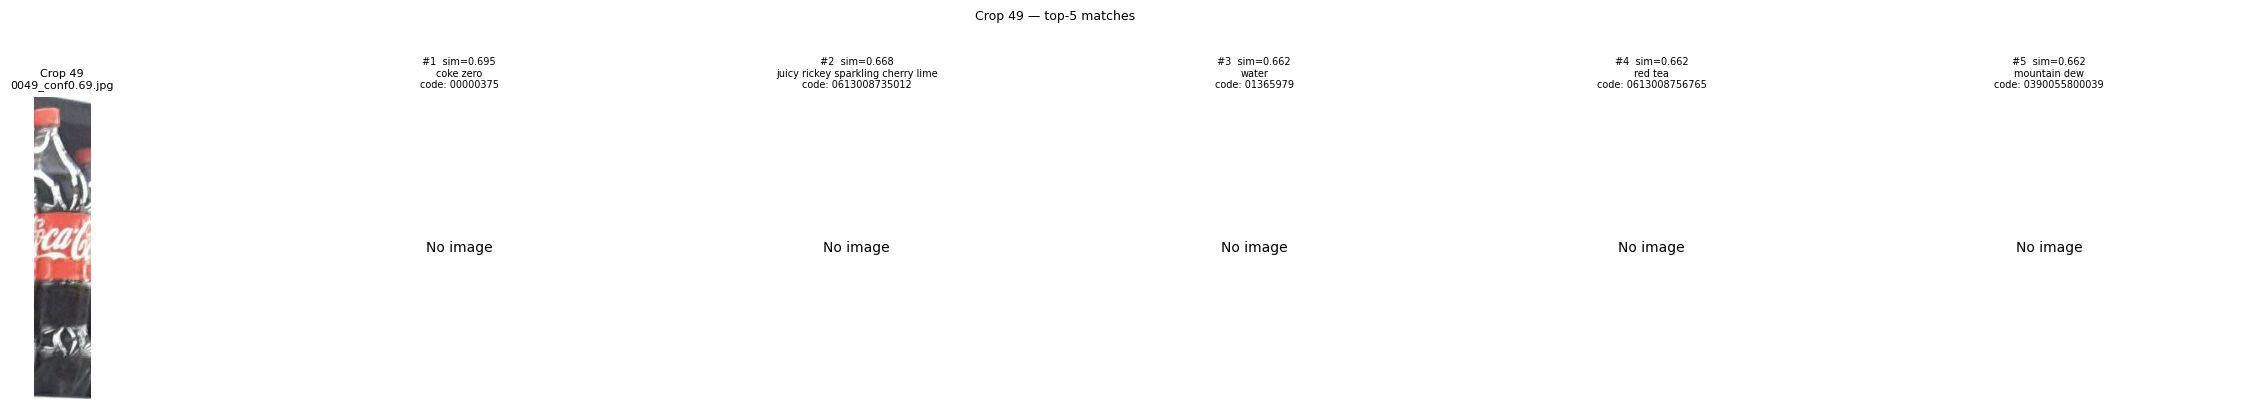


  Crop 49 best matches:
    #1  sim=0.6952  code=00000375  name=coke zero
         url=https://images.openfoodfacts.org/images/products/000/000/000/0375/front_fr.16.400.jpg
    #2  sim=0.6680  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #3  sim=0.6622  code=01365979  name=water
         url=https://images.openfoodfacts.org/images/products/000/000/136/5979/front_fr.3.400.jpg
    #4  sim=0.6622  code=0613008756765  name=red tea
         url=https://images.openfoodfacts.org/images/products/061/300/875/6765/front_fr.23.400.jpg
    #5  sim=0.6620  code=0390055800039  name=mountain dew
         url=https://images.openfoodfacts.org/images/products/039/005/580/0039/front_fr.3.400.jpg



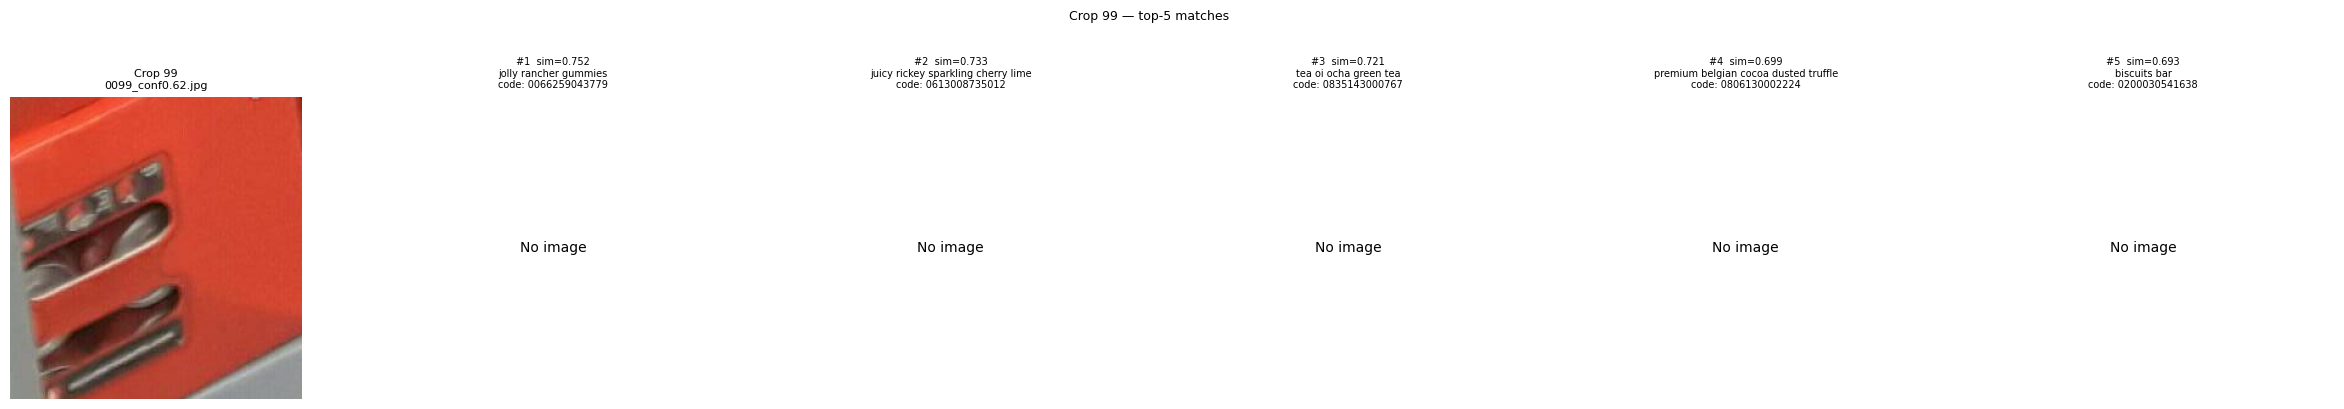


  Crop 99 best matches:
    #1  sim=0.7519  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg
    #2  sim=0.7334  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #3  sim=0.7211  code=0835143000767  name=tea oi ocha green tea
         url=https://images.openfoodfacts.org/images/products/083/514/300/0767/front_fr.16.400.jpg
    #4  sim=0.6992  code=0806130002224  name=premium belgian cocoa dusted truffle
         url=https://images.openfoodfacts.org/images/products/080/613/000/2224/front_en.3.400.jpg
    #5  sim=0.6927  code=0200030541638  name=biscuits bar
         url=https://images.openfoodfacts.org/images/products/020/003/054/1638/front_fr.15.400.jpg



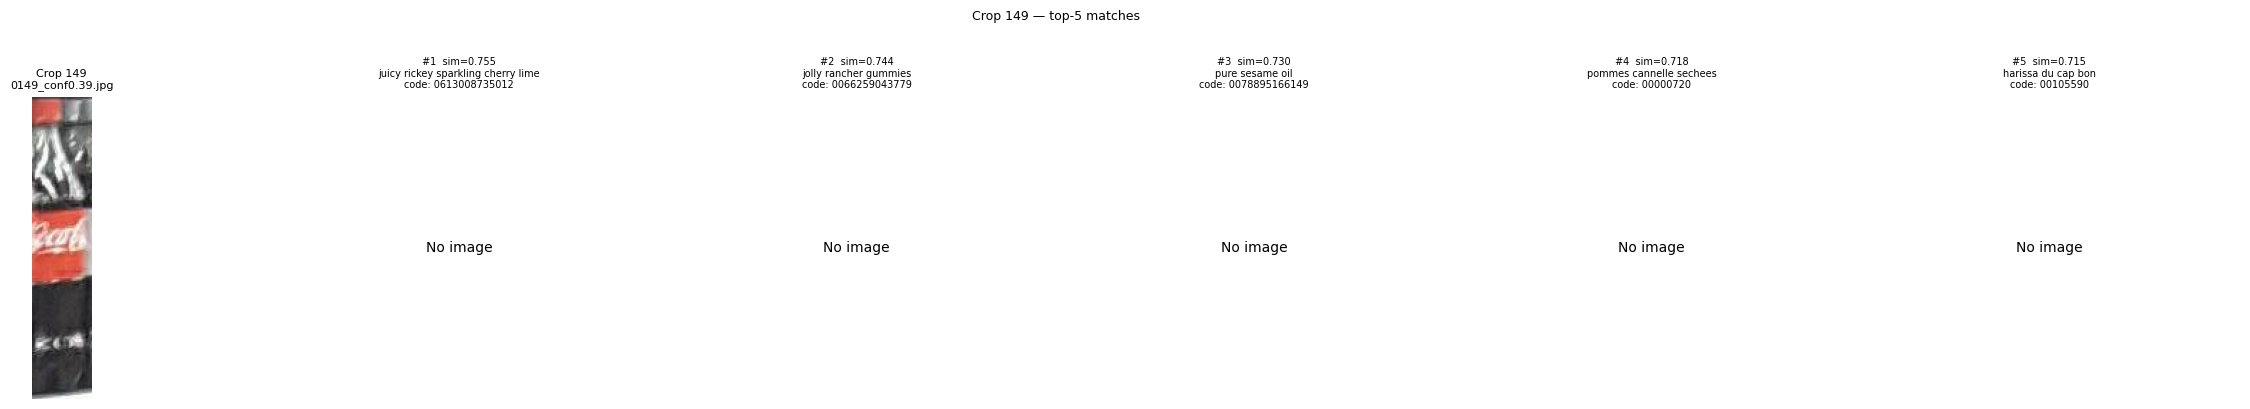


  Crop 149 best matches:
    #1  sim=0.7553  code=0613008735012  name=juicy rickey sparkling cherry lime
         url=https://images.openfoodfacts.org/images/products/061/300/873/5012/front_fr.40.400.jpg
    #2  sim=0.7442  code=0066259043779  name=jolly rancher gummies
         url=https://images.openfoodfacts.org/images/products/006/625/904/3779/front_en.23.400.jpg
    #3  sim=0.7299  code=0078895166149  name=pure sesame oil
         url=https://images.openfoodfacts.org/images/products/007/889/516/6149/front_en.23.400.jpg
    #4  sim=0.7181  code=00000720  name=pommes cannelle sechees
         url=https://images.openfoodfacts.org/images/products/000/000/000/0720/front_en.17.400.jpg
    #5  sim=0.7148  code=00105590  name=harissa du cap bon
         url=https://images.openfoodfacts.org/images/products/000/000/010/5590/front_en.3.400.jpg



In [15]:
# Pick 5 consistent indices spread across all results
n_total = len(all_results)
sample_indices = sorted(set([
    min(4, n_total - 1),                    # ~crop 5
    min(24, n_total - 1),                   # ~crop 25
    min(49, n_total - 1),                   # ~crop 50
    min(99, n_total - 1),                   # ~crop 100
    min(149, n_total - 1),                  # ~crop 150
]))
print(f"Showing crops: {sample_indices} (out of {n_total} total)")

for crop_idx in sample_indices:
    crop_pil, crop_path, matches = all_results[crop_idx]
    n_matches = len(matches)
    fig, axes = plt.subplots(1, 1 + n_matches, figsize=(4 * (1 + n_matches), 4))
    if n_matches == 0:
        axes = [axes]

    axes[0].imshow(crop_pil)
    axes[0].set_title(f"Crop {crop_idx}\n{crop_path.name}", fontsize=8)
    axes[0].axis("off")

    for rank, (ax, m) in enumerate(zip(axes[1:], matches), start=1):
        match_img = fetch_pil(m["image_url"]) if m["image_url"] else None
        if match_img:
            ax.imshow(match_img)
        else:
            ax.text(0.5, 0.5, "No image", ha="center", va="center", transform=ax.transAxes)

        title = (
            f"#{rank}  sim={m['similarity']:.3f}\n"
            f"{m['product_name']}\n"
            f"code: {m['code']}"
        )
        ax.set_title(title, fontsize=7)
        ax.axis("off")

    plt.suptitle(f"Crop {crop_idx} — top-{n_matches} matches", fontsize=9, y=1.01)
    plt.tight_layout()
    plt.savefig(run_dir / f"{crop_idx:04d}_matches.png", bbox_inches="tight", dpi=120)
    plt.show()
    print()

    print(f"  Crop {crop_idx} best matches:")
    for rank, m in enumerate(matches, 1):
        print(f"    #{rank}  sim={m['similarity']:.4f}  "
              f"code={m['code']}  name={m['product_name']}")
        print(f"         url={m['image_url']}")
    print()

In [17]:
# Check what a freshly embedded dataset image looks like vs a cached one
query_img = fetch_pil("https://images.openfoodfacts.org/images/products/544/900/005/4227/front_en.406.400.jpg")

fresh_vec = fused_embed(query_img)

cache_file = Path("./faiss_progress") / f"row_{398:07d}.npy"  # first coke entry
cached_vec = np.load(str(cache_file))

print(f"Fresh vec  — first 512 (CLIP):  mean={fresh_vec[:512].mean():.4f}  std={fresh_vec[:512].std():.4f}")
print(f"Fresh vec  — next 512 (OCR):    mean={fresh_vec[512:1024].mean():.4f}  std={fresh_vec[512:1024].std():.4f}")
print()
print(f"Cached vec — first 512 (CLIP):  mean={cached_vec[:512].mean():.4f}  std={cached_vec[:512].std():.4f}")
print(f"Cached vec — next 512 (OCR):    mean={cached_vec[512:1024].mean():.4f}  std={cached_vec[512:1024].std():.4f}")


Fresh vec  — first 512 (CLIP):  mean=0.0009  std=0.0342
Fresh vec  — next 512 (OCR):    mean=0.0024  std=0.0279

Cached vec — first 512 (CLIP):  mean=-0.0008  std=0.0341
Cached vec — next 512 (OCR):    mean=0.0014  std=0.0272


In [33]:
test_crop_pil = all_results[0][0]

# Dit test voor clip 70%, 50% en 30%, idem voor Florence-2
for cw, fw in [(0.7, 0.3), (0.5, 0.5), (0.3, 0.7), 
               (0.45, 0.55), (0.425, 0.575), (0.475, 0.525)
               ,(0.525, 0.475), (0.55, 0.45), (0.575, 0.425)]:
    orig_c, orig_f = CLIP_WEIGHT, OCR_WEIGHT
    CLIP_WEIGHT, OCR_WEIGHT = cw, fw

    top1 = search(test_crop_pil, k=1)
    m    = top1[0] if top1 else {}
    print(f"CLIP={cw} / FL2={fw}  →  {m.get('product_name')}  sim={m.get('similarity', 0):.4f}")

    CLIP_WEIGHT, OCR_WEIGHT = orig_c, orig_f

CLIP=0.7 / FL2=0.3  →  Coca-Cola  sim=0.8424
CLIP=0.5 / FL2=0.5  →  Coca-Cola  sim=0.8902
CLIP=0.3 / FL2=0.7  →  Coca light 1.5l  sim=0.8153
CLIP=0.45 / FL2=0.55  →  Coca-Cola  sim=0.8815
CLIP=0.425 / FL2=0.575  →  Coca-Cola  sim=0.8740
CLIP=0.475 / FL2=0.525  →  Coca-Cola  sim=0.8869
CLIP=0.525 / FL2=0.475  →  Coca-Cola  sim=0.8912
CLIP=0.55 / FL2=0.45  →  Coca-Cola  sim=0.8900
CLIP=0.575 / FL2=0.425  →  Coca-Cola  sim=0.8867


In [ ]:
# Build a controlled test: pick 10 specific products, index them,
# then query with their own image and see if top-1 is correct
test_products = meta_df.sample(10, seed=42)

correct = 0
for row in test_products.iter_rows(named=True):
    img = fetch_pil(row["image_url"])
    if img is None:
        continue
    matches = search(img, k=1)
    top1_code = matches[0]["code"] if matches else None
    hit = top1_code == row["code"]
    correct += hit
    print(f"{'✓' if hit else '✗'}  {row['product_name'][:40]}  → matched: {matches[0]['product_name'][:40]}  sim={matches[0]['similarity']:.4f}")

print(f"\nTop-1 accuracy: {correct}/{len(test_products)}")